Poligonos encontrados: 29
Rectangulo: 28 4267.151280000001
Tierra principal: 27 2614.4646804427693
Islas: 26
Tipo: MultiPolygon
Eliminando franja izquierda
Vertices: 46432
Segmentos: 46432
Holes: 22


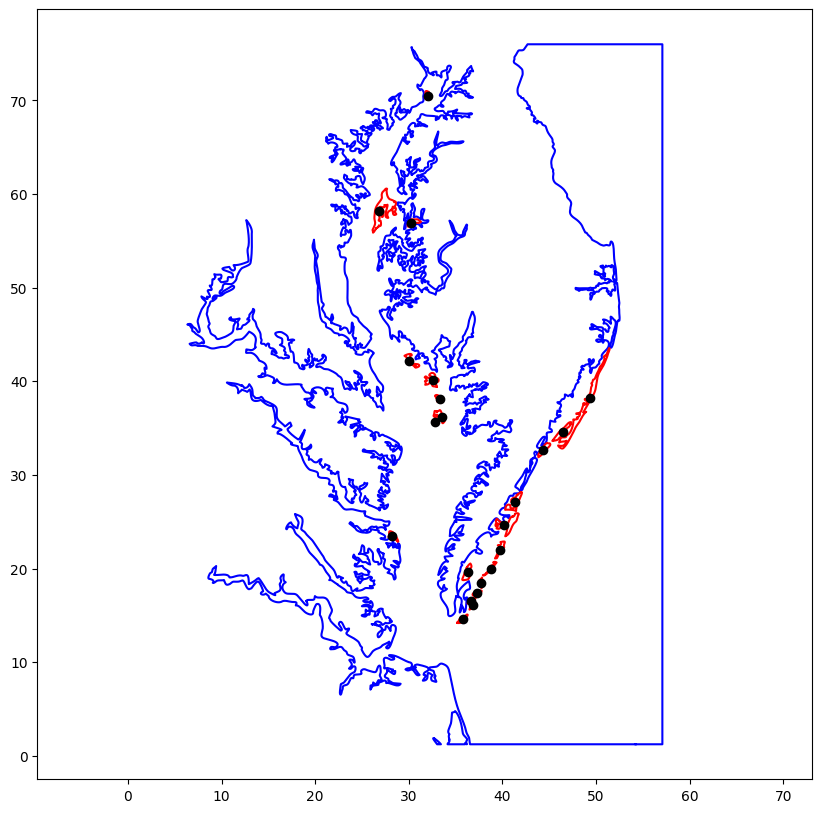


Archivo generado: chesapeake.poly


In [10]:
from svgpathtools import svg2paths
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

SVG_FILE = "Chesapeake-Bay.svg"
POLY_FILE = "chesapeake_water.poly"
MALLAR_TIERRA = True
SVG_HEIGHT = 76
SAMPLES_PER_SEGMENT = 20

CLOSE_TOL = 0.05
MIN_POLY_AREA = 1e-3
MIN_ISLAND_AREA = 0.01

if MALLAR_TIERRA == True:
    POLY_FILE = "chesapeake.poly"
else:
    POLY_FILE = "chesapeake_water.poly"
# ============================================================
# LEER SVG
# ============================================================

paths, attrs = svg2paths(SVG_FILE)

polygons = []

for path in paths:

    for subpath in path.continuous_subpaths():

        if len(subpath) == 0:
            continue

        start = subpath[0].start
        end = subpath[-1].end

        if abs(start - end) > CLOSE_TOL:
            continue

        pts = []

        for seg_idx, segment in enumerate(subpath):

            ts = np.linspace(
                0,
                1,
                SAMPLES_PER_SEGMENT,
                endpoint=(seg_idx == len(subpath) - 1)
            )

            for t in ts:

                z = segment.point(t)

                x = float(z.real)
                y = float(SVG_HEIGHT - z.imag)

                pts.append((x, y))

        try:

            poly = Polygon(pts)

            if not poly.is_valid:
                poly = poly.buffer(0)

            if poly.is_empty:
                continue

            if poly.area > MIN_POLY_AREA:
                polygons.append(poly)

        except Exception:
            pass

print("Poligonos encontrados:", len(polygons))

# ============================================================
# RECTANGULO EXTERIOR
# ============================================================

ratios = []

for poly in polygons:

    minx, miny, maxx, maxy = poly.bounds

    bbox_area = (maxx - minx) * (maxy - miny)

    ratios.append(poly.area / bbox_area)

rect_idx = np.argmax(ratios)

rect_poly = polygons[rect_idx]

print("Rectangulo:", rect_idx, rect_poly.area)

# ============================================================
# TIERRA PRINCIPAL
# ============================================================

land_idx = np.argmax([
    p.area if i != rect_idx else -1
    for i, p in enumerate(polygons)
])

land_poly = polygons[land_idx]

print("Tierra principal:", land_idx, land_poly.area)

# ============================================================
# ISLAS
# ============================================================

islands = []

for i, poly in enumerate(polygons):

    if i == rect_idx:
        continue

    if i == land_idx:
        continue

    if poly.area < MIN_ISLAND_AREA:
        continue

    islands.append(poly)

print("Islas:", len(islands))

# ============================================================
# AGUA
# ============================================================

if MALLAR_TIERRA is True:

    water = rect_poly.difference(land_poly)

    for island in islands:
        water = water.difference(island)

    if water.is_empty:
        raise RuntimeError("La geometria del agua quedo vacia")

    print("Tipo:", water.geom_type)

    if isinstance(water, MultiPolygon):
        keep = []

        for g in water.geoms:

            minx, miny, maxx, maxy = g.bounds

            if minx < 0.1 and (maxx - minx) < 0.1:
                print("Eliminando franja izquierda")
                continue

            keep.append(g)

        water = MultiPolygon(keep)

        

# ============================================================
# Tierra
# ============================================================

else:

    land_parts = [land_poly]

    for island in islands:
        land_parts.append(island)

    land_poly = unary_union(land_parts)

    if land_poly.is_empty:
        raise RuntimeError("La geometria del agua quedo vacia")

    print("Tipo:", land_poly.geom_type)

    if isinstance(land_poly, MultiPolygon):
        print("Componentes:", len(land_poly.geoms))

    water = land_poly

# ============================================================
# GENERAR PSLG DESDE WATER
# ============================================================

vertices = []
edges = []

vid = 1

hole_points = []

def add_ring(coords, vertices, edges, vid):

    ids = []

    coords = list(coords)

    # eliminar ultimo punto repetido
    coords = coords[:-1]

    for x, y in coords:

        vertices.append((vid, float(x), float(y))
        )

        ids.append(vid)

        vid += 1

    n = len(ids)

    for i in range(n):

        edges.append(
            (
                ids[i],
                ids[(i + 1) % n]
            )
        )

    return vid


if isinstance(water, Polygon):

    water_components = [water]

else:

    water_components = list(water.geoms)

for comp in water_components:

    # contorno exterior del componente de agua

    vid = add_ring(
        comp.exterior.coords,
        vertices,
        edges,
        vid
    )

    # agujeros internos del componente
    # (estas son las islas)

    for interior in comp.interiors:

        vid = add_ring(
            interior.coords,
            vertices,
            edges,
            vid
        )

        hole_poly = Polygon(interior.coords)

        p = hole_poly.representative_point()

        hole_points.append(
            (p.x, p.y)
        )


# ============================================================
# AGREGAR BORDE DERECHO DEL RECTANGULO
# ============================================================
# if MALLAR_TIERRA == False :

#     minx, miny, maxx, maxy = rect_poly.bounds

#     v1 = vid
#     vertices.append((vid, maxx, miny))
#     vid += 1

#     v2 = vid
#     vertices.append((vid, maxx, maxy))
#     vid += 1

#     edges.append((v1, v2))


print("Vertices:", len(vertices))
print("Segmentos:", len(edges))
print("Holes:", len(hole_points))

# ============================================================
# REGION DE AGUA
# ============================================================

seed = water.representative_point()

# ============================================================
# VISUALIZACION
# ============================================================

plt.figure(figsize=(10, 10))

for comp in water_components:

    x, y = comp.exterior.xy

    plt.plot(x, y, "b")

    for interior in comp.interiors:

        xh, yh = zip(*list(interior.coords))

        plt.plot(xh, yh, "r")

for hx, hy in hole_points:
    plt.plot(hx, hy, "ko")

# segmento derecho del rectángulo
# if  MALLAR_TIERRA == False :
#     x_seg = [maxx, maxx]
#     y_seg = [miny, maxy]

#     plt.plot(
#         x_seg,
#         y_seg,
#         "b",
#         label="Borde derecho"
#     )

plt.axis("equal")
plt.show()

# ============================================================
# ESCRIBIR POLY
# ============================================================

with open(POLY_FILE, "w") as f:

    # vertices

    f.write(f"{len(vertices)} 2 0 0\n")

    for vid_, x, y in vertices:

        f.write(
            f"{vid_} "
            f"{x:.8f} "
            f"{y:.8f}\n"
        )

    # segmentos

    f.write(f"{len(edges)} 0\n")

    for sid, (v1, v2) in enumerate(edges, start=1):

        f.write(
            f"{sid} "
            f"{v2} " #v1
            f"{v1}\n" #v2
        )

    # holes

    f.write(f"{len(hole_points)}\n")

    for hid, (hx, hy) in enumerate(hole_points, start=1):

        f.write(
            f"{hid} "
            f"{hx:.8f} "
            f"{hy:.8f}\n"
        )

    # regions

    f.write("1\n")

    f.write(
        f"1 "
        f"{seed.x:.8f} "
        f"{seed.y:.8f} "
        f"1 "
        f"0\n"
    )

print()
print("Archivo generado:", POLY_FILE)